In [1]:
%pip install --quiet PySpark

from pyspark.sql import functions,SparkSession
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ipywidgets import interact, widgets
import numpy as np


import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [2]:
spark = SparkSession \
    .builder \
    .appName("fero") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/23 21:50:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
rawdf = spark.read.option("header",True).csv("cleaned_transactions.csv")

# Cleaning input column names

rawdf = rawdf.withColumnRenamed('product_category.id', 'product_category_id') \
       .withColumnRenamed('product_category.name', 'product_category_name') \
       .withColumnRenamed('region.id', 'region_id') \
       .withColumnRenamed('region.name', 'region_name') \
       .withColumnRenamed('region.country.id', 'region_country_id') \
       .withColumnRenamed('region.country.name', 'region_country_name') \
       .withColumnRenamed('sub_varietal.id', 'sub_varietal_id') \
       .withColumnRenamed('sub_varietal.name', 'sub_varietal_name') \
       .withColumnRenamed('brand.id', 'brand_id') \
       .withColumnRenamed('brand.name', 'brand_name') \
       .withColumnRenamed('attribute_json.abv','attribute_json_abv') \
       .withColumnRenamed('attribute_json.bottle_ml','attribute_json_bottle_ml') \
       .withColumnRenamed('attribute_json.year','attribute_json_year') \
       .withColumnRenamed('attribute_json.age','attribute_json_age') \
       .withColumnRenamed('attribute_json.grape_variety','attribute_json_grape_variety') \
       .withColumnRenamed('attribute_json.grain_variety','attribute_json_grain_variety') \
       .withColumnRenamed('attribute_json.blend','attribute_json_blend') \
       .withColumnRenamed('attribute_json.barrel_type','attribute_json_barrel_type') \
       .withColumnRenamed('timestamp','snapshot_time')
       
rawdf.createOrReplaceTempView("raw")

# rawdf.show()

25/03/23 21:50:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


### Star Schema

I'm breaking up the raw dataset into 4 dimensions (SKU, Product Category, Region, and Time), and 1 fact table for Transactions data. This should be agnostic of the business problem(s) for which I am performing my analyses below.

![Data Model](fero_datamodel.png)

In [5]:
f_transactions = spark.sql("""
    select _c0 as txn_id, 
            unix_timestamp(snapshot_time) as time_id,
            sku_code,
            cast(product_category_id as int) product_category_id,
            cast(region_id as int) region_id,
            cast(region_country_id as int) region_country_id,
            cast(sub_varietal_id as int) sub_varietal_id,
            cast(brand_id as int) brand_id,
            transaction_type,
            cast(quantity as int) quantity,
            cast(unit_price as float) unit_price,
            cast(revenue as float) revenue,
            cast(cost as float) cost,
            cast(realized_profit as float) realized_profit
    from raw
    group by 1,2,3,4,5,6,7,8,9,10,11,12,13,14
    """
)

f_transactions.createOrReplaceTempView("f_transactions")

d_skus = spark.sql("""
    select 
        sku_code, 
        cast(brand_id as int) brand_id,
        brand_name,
        cast(attribute_json_abv as float) abv,
        cast(attribute_json_bottle_ml as int) bottle_ml,
        cast(attribute_json_year as int) year,
        cast(attribute_json_age as int) age,
        attribute_json_grape_variety grape_variety,
        attribute_json_grain_variety grain_variety,
        attribute_json_blend blend,
        attribute_json_barrel_type barrel_type
    from raw
    group by 1,2,3,4,5,6,7,8,9,10,11
    """
)

d_skus.createOrReplaceTempView("d_skus")

d_products = spark.sql("""
    select cast(product_category_id as int) product_category_id,
            product_category_name,
            cast(sub_varietal_id as int) sub_varietal_id,
            sub_varietal_name
    from raw
    group by 1,2,3,4
"""
)
d_products.createOrReplaceTempView("d_products")

d_regions = spark.sql("""
    select cast(region_id as int) region_id,
            region_name,
            cast(region_country_id as int) region_country_id,
            region_country_name
    from raw
    group by 1,2,3,4
"""
)

d_regions.createOrReplaceTempView("d_regions")

d_time = spark.sql("""
    select unix_timestamp(snapshot_time) as time_id
            , snapshot_time
            , date_format(snapshot_time, 'yyyy-MM-dd') as snapshot_date
            , date_format(snapshot_time, 'yyyy-MM') as snapshot_month
            ,year(snapshot_time) as year
            ,dayofweek(snapshot_time) as day_of_week
    from raw
    group by 1,2,3,4,5,6
"""
)

d_time.createOrReplaceTempView("d_time")

# f_transactions.show(24)


## Question 1: Finance Datamart

`Our finance team wants to know more about the financial performance of the SKUs being bought and sold. At the end of each month, identify the top 3 SKUs with the highest realised profit. Bonus: determine the net inventory position (current inventory value) at the end of each month.`

Identifying top 3 SKUs each month, ordered by realized profit. Also, calculating the net inventory position by summing up quantity over all preceding rows. Grouping this by snapshot_month will give us the total profit and the inventory position at the end of each month.

In [7]:
# first, create a view of net profit, rolling inventory position at a monthly level, and monthly rank of the SKUs by profit

monthly_txns = spark.sql("""
    select  f.sku_code,
            t.snapshot_month,
            t.year,
            f.brand_id,
            f.product_category_id,
            f.sub_varietal_id,
            f.region_id,
            f.region_country_id,
            sum(f.realized_profit) as tot_profit,
            sum(sum(f.quantity)) over (
                partition by f.sku_code 
                order by t.snapshot_month 
                rows between unbounded preceding and current row
            ) as net_inventory_position,
            dense_rank() over (partition by snapshot_month order by sum(f.realized_profit) desc) as rank
    from f_transactions f
    join d_time t
        on f.time_id = t.time_id
    group by 1,2,3,4,5,6,7,8
""")

monthly_txns.createOrReplaceTempView("monthly_txns")

# reporting dataset on which to base the analysis and visualizations

top_3_monthly = spark.sql("""
          select a.sku_code,
            a.snapshot_month,
            a.year,
            a.rank,
            cast(a.tot_profit as decimal(10,2)) as tot_profit,
            a.net_inventory_position,
            b.brand_name,
            c.product_category_name,
            c.sub_varietal_name,
            d.region_name,
            d.region_country_name,
            b.age
        from monthly_txns a
        join d_skus b
            on a.sku_code = b.sku_code
        join d_products c
            on a.product_category_id = c.product_category_id
            and a.sub_varietal_id = c.sub_varietal_id
        join d_regions d
            on a.region_id = d.region_id
            and a.region_country_id = d.region_country_id
        where 1=1
        and a.rank <= 3
        order by a.snapshot_month, a.rank
""")

top_3_monthly_df = top_3_monthly.toPandas()
top_3_monthly_df['snapshot_month'] = pd.to_datetime(top_3_monthly_df['snapshot_month'])
top_3_monthly_df['product_name'] = top_3_monthly_df['brand_name'] + ' - ' + top_3_monthly_df['sub_varietal_name'] + ' - ' + top_3_monthly_df['age'].astype(str) + 'y'
top_3_monthly_df.head(100)


25/03/23 21:50:05 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
 Schema: _c0, timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
Expected: _c0 but found: 
CSV file: file:///Users/mk/fero/cleaned_transactions.csv
Java HotSpot(TM) 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
Java HotSpot(TM) 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=28345Kb max_used=29089Kb free=102726Kb
 bounds [0x0000000106c64000, 0x0000000108914000, 0x000000010ec64000]
 total_blobs=10513 nmethods=9572 adapters=850
 compilation: disabled (not enough contiguous free space left)


,sku_code,snapshot_month,year,rank,tot_profit,net_inventory_position,brand_name,product_category_name,sub_varietal_name,region_name,region_country_name,age,product_name
0,BRBN-MAK-024,2020-01-01,2020,1,373789.44,2366,Makers Mark,Bourbon,Rye,Kentucky,United States,32,Makers Mark - Rye - 32y
1,BRBN-BUF-019,2020-01-01,2020,2,103696.04,1460,Buffalo Trace,Bourbon,Straight Bourbon,Kentucky,United States,13,Buffalo Trace - Straight Bourbon - 13y
2,WHKY-MAC-014,2020-01-01,2020,3,39798.04,2678,Macallan,Whisky,Blended Malt,Highland,Scotland,10,Macallan - Blended Malt - 10y
3,BRBN-BUF-019,2020-02-01,2020,1,157072.95,1651,Buffalo Trace,Bourbon,Straight Bourbon,Kentucky,United States,13,Buffalo Trace - Straight Bourbon - 13y
4,BRBN-PAP-021,2020-02-01,2020,2,66815.06,1874,Pappy Van Winkle,Bourbon,Straight Bourbon,Kentucky,United States,7,Pappy Van Winkle - Straight Bourbon - 7y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,WHKY-MAC-013,2022-08-01,2022,3,134525.79,18643,Macallan,Whisky,Single Malt,Islay,Scotland,16,Macallan - Single Malt - 16y
96,BRBN-MAK-024,2022-09-01,2022,1,12587632.40,57710,Makers Mark,Bourbon,Rye,Kentucky,United States,32,Makers Mark - Rye - 32y
97,WHKY-MAC-014,2022-09-01,2022,2,557618.01,20408,Macallan,Whisky,Blended Malt,Highland,Scotland,10,Macallan - Blended Malt - 10y
98,BRBN-BUF-019,2022-09-01,2022,3,26219.94,23805,Buffalo Trace,Bourbon,Straight Bourbon,Kentucky,United States,13,Buffalo Trace - Straight Bourbon - 13y


### Insights

Of the 24 unique SKUs we have, let's try to find the ones that show up most often in the monthly top 3, and find our most consistently profitable SKUs.

In [9]:

def plot_filtered_data(start_date, end_date):
    plt.clf()
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    

    filtered_df = top_3_monthly_df[
        (top_3_monthly_df['snapshot_month'] >= start_date) &
        (top_3_monthly_df['snapshot_month'] <= end_date)
    ]


    sku_to_product_name = top_3_monthly_df.set_index('sku_code')['product_name'].to_dict()

    rank_counts = top_3_monthly_df.groupby(['sku_code', 'rank']).size().reset_index(name='count')

    pivot_df = rank_counts.pivot(index='sku_code', columns='rank', values='count').fillna(0)

    pivot_df['total_count'] = pivot_df.sum(axis=1)  # temporary column for total counts, to sort by on the  x-axis
    pivot_df = pivot_df.sort_values(by='total_count', ascending=False)
    pivot_df = pivot_df.drop(columns=['total_count'])  


    x = np.arange(len(pivot_df.index))  
    bar_width = 0.25  


    plt.figure(figsize=(18, 12))
    for i, rank in enumerate(pivot_df.columns):
        bars = plt.bar(
            x + i * bar_width,
            pivot_df[rank],  
            width=bar_width,
            label=f'Rank {rank}'
        )

        for bar in bars:
                height = bar.get_height()
                if height > 0:  
                    plt.text(
                        bar.get_x() + bar.get_width() / 2, 
                        height,
                        f'{int(height)}',
                        ha='center',  
                        va='bottom',  
                        fontsize=10  
                    )



    plt.title(f'Frequency of SKU Codes by Rank in Top 3, Realized Profit ({start_date.date()} to {end_date.date()})')
    plt.xlabel('SKU Code')
    plt.ylabel('Count')
    plt.xticks(
        ticks=x + bar_width,
        labels=[f"{sku}\n({sku_to_product_name[sku]})" for sku in pivot_df.index],
        rotation=90
    )
    plt.legend(title='Rank')
    plt.tight_layout()
    plt.show()

# interactive widget for start and end dates
start_date_widget = widgets.DatePicker(description='Start Date', value=pd.to_datetime('2020-01-01').date())
end_date_widget = widgets.DatePicker(description='End Date', value=pd.to_datetime('2025-01-01').date())

interact(plot_filtered_data, start_date=start_date_widget, end_date=end_date_widget)

interactive(children=(DatePicker(value=datetime.date(2020, 1, 1), description='Start Date', step=1), DatePicke…

<function __main__.plot_filtered_data(start_date, end_date)>

### What do we see?

By far, one of our most consistently profitable SKUs is `BRBN-BUF-019`, which is the 13 year old Straight Bourbon by Buffalo Trace. Of the 61 months in our dataset (jan 2020 - jan 2025), this SKU ranked #1- 25 times, #2- 10 times, and #3- 5 times.  However, **this does not mean this is _the most profitable_ SKU**. This above chart only shows us that, across all the months' worth of data we have, this SKU has fairly consistently ranked amongst the top 3 most profitable SKUs each month.

The chart also shows the same data for other SKUs that have ranked amongst the top 3 by month.

### How does this differ from _most profitable_?

This dataset merely captures the SKUs that are profitable, and as such, excludes months where a SKU might have generated a net realized loss. This means that while we see a SKU like `BRBN-MAK-024` (Maker's Mark, Rye, 32y) second on this list, we don't capture the fact that for _half_ the months in 2020, we realized a net loss for this SKU, as seen below.

In [11]:
spark.sql("""
    select  f.sku_code,
            t.snapshot_month,
            t.year,
            sum(f.realized_profit) as tot_profit
    from f_transactions f
    join d_time t
        on f.time_id = t.time_id
    where f.sku_code = 'BRBN-MAK-024'
    and t.year = 2020
    group by 1,2,3
    order by t.snapshot_month
""").show()

25/03/23 21:50:08 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
 Schema: _c0, timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
Expected: _c0 but found: 
CSV file: file:///Users/mk/fero/cleaned_transactions.csv


+------------+--------------+----+-------------------+
|    sku_code|snapshot_month|year|         tot_profit|
+------------+--------------+----+-------------------+
|BRBN-MAK-024|       2020-01|2020|  373789.4414367718|
|BRBN-MAK-024|       2020-02|2020| -61291.37234497309|
|BRBN-MAK-024|       2020-03|2020| 1422341.3456516233|
|BRBN-MAK-024|       2020-04|2020| -3169466.484603882|
|BRBN-MAK-024|       2020-05|2020|  843146.3901500702|
|BRBN-MAK-024|       2020-06|2020| 3327636.3295583725|
|BRBN-MAK-024|       2020-07|2020| 2650543.8358154297|
|BRBN-MAK-024|       2020-08|2020| -2418756.072166443|
|BRBN-MAK-024|       2020-09|2020|-3272080.5838928223|
|BRBN-MAK-024|       2020-10|2020| -996702.8123931885|
|BRBN-MAK-024|       2020-11|2020|  9210855.588363647|
|BRBN-MAK-024|       2020-12|2020| -9647608.981781006|
+------------+--------------+----+-------------------+



Here's an interactive visualisation that lets users view the Top 3 SKUs and their profit, by month, for a date range of their choosing.

In [13]:

def plot_filtered_data(start_date, end_date):
    plt.clf()
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    

    filtered_df = top_3_monthly_df[
        (top_3_monthly_df['snapshot_month'] >= start_date) &
        (top_3_monthly_df['snapshot_month'] <= end_date)
    ]
    

    pivot_df = filtered_df.pivot(index='snapshot_month', columns='sku_code', values='tot_profit')

    pivot_df = pivot_df.apply(pd.to_numeric, errors='coerce')
    

    ax = pivot_df.plot(kind='bar', figsize=(18, 12), width=0.8)
    plt.title(f'Top 3 SKUs by Profit ({start_date.date()} to {end_date.date()})')
    plt.xlabel('Month')
    plt.ylabel('Total Profit (£)')
    plt.legend(title='SKU')
    plt.xticks(rotation=45)
    

    for container, sku_code in zip(ax.containers, pivot_df.columns):
        for bar in container:
            height = bar.get_height()
            rounded_height = height / 1_000_000  # Round to millions
            if height > 0:  
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,  
                    f'£{rounded_height:,.1f}M',
                    ha='center', 
                    va='bottom',
                    fontsize=6, 
                    rotation=45 
                )

                ax.text(
                    bar.get_x() + bar.get_width() / 2,  
                    -0.5,  
                    f'{sku_code}',  
                    ha='center', 
                    va='top',
                    fontsize=8, 
                    rotation=90
                )
    
    plt.show()

# interactive widget for start and end dates
start_date_widget = widgets.DatePicker(description='Start Date', value=pd.to_datetime('2024-01-01').date())
end_date_widget = widgets.DatePicker(description='End Date', value=pd.to_datetime('2024-12-01').date())

interact(plot_filtered_data, start_date=start_date_widget, end_date=end_date_widget)


interactive(children=(DatePicker(value=datetime.date(2024, 1, 1), description='Start Date', step=1), DatePicke…

<function __main__.plot_filtered_data(start_date, end_date)>

## Question 2: Operations Datamart

`Our operations team wants to know more about the inventory management of SKUs we hold. At the end of each month, identify the top 3 SKUs with the highest inventory turnover rates. Bonus: highlight which SKUs are risk of stockouts (inventory levels below 1,000 units) at the end of each month.`

Assumption: Inventory Turnover rate  = number of units sold / average number of units on hand. [source.](https://www.linnworks.com/blog/calculate-inventory-turnover/#:~:text=In%20addition%20to%20using%20financial,on%20hand%20=%20Inventory%20turnover%20rate)

In [15]:
# Creating operations datamart: captures total units sold, starting and ending inventory positions, calculates turnover rates,
# and flags stockouts as defined in the problem statement

ops_txns = spark.sql("""
    with cte as(
    select  f.sku_code,
            t.snapshot_month,
            t.year,
            f.brand_id,
            f.product_category_id,
            f.sub_varietal_id,
            f.region_id,
            f.region_country_id,
            sum(case when f.transaction_type = 'SELL' then abs(quantity) else 0 end) as units_sold,
            nvl(sum(sum(f.quantity)) over (
                partition by f.sku_code 
                order by t.snapshot_month 
                rows between unbounded preceding and 1 preceding
            ),0) as starting_inventory_position,
            sum(sum(f.quantity)) over (
                partition by f.sku_code 
                order by t.snapshot_month 
                rows between unbounded preceding and current row
            ) as ending_inventory_position,
            units_sold / ((starting_inventory_position + ending_inventory_position)/2) as inventory_turnover,
            case when ending_inventory_position <1000 then 1 else 0 end as stockout_flag        
    from f_transactions f
    join d_time t
        on f.time_id = t.time_id
    group by 1,2,3,4,5,6,7,8
    )
    select sku_code,
            snapshot_month,
            year,
            brand_id,
            product_category_id,
            sub_varietal_id,
            region_id,
            region_country_id,
            units_sold,
            starting_inventory_position,
            ending_inventory_position,
            inventory_turnover,
            stockout_flag,
            dense_rank() over (partition by snapshot_month order by inventory_turnover desc) as rank
    from cte
""")

# ops_txns.show(25)
ops_txns.createOrReplaceTempView("ops_txns")

# Identifying top 3 SKUs each month by inventory turnover rates

top_3_monthly_ops = spark.sql("""
            select a.sku_code,
                a.snapshot_month,
                a.year,
                a.rank,
                cast(a.units_sold as int) as units_sold,
                cast(a.starting_inventory_position as int) as starting_inventory_position,
                cast(a.ending_inventory_position as int) as ending_inventory_position,
                a.inventory_turnover,
                a.stockout_flag,
                b.brand_name,
                b.age,
                c.product_category_name,
                c.sub_varietal_name,
                d.region_name,
                d.region_country_name
            from ops_txns a
            join d_skus b
                on a.sku_code = b.sku_code
            join d_products c
                on a.product_category_id = c.product_category_id
                and a.sub_varietal_id = c.sub_varietal_id
            join d_regions d
                on a.region_id = d.region_id
                and a.region_country_id = d.region_country_id
            where 1=1
            and a.rank <= 3
            order by a.snapshot_month, a.rank
""")

# top_3_monthly_ops.show(183)
top_3_monthly_ops.createOrReplaceTempView("top_3_monthly_ops")
top_3_monthly_ops_df = top_3_monthly_ops.toPandas()
top_3_monthly_ops_df['snapshot_month'] = pd.to_datetime(top_3_monthly_ops_df['snapshot_month'])
top_3_monthly_ops_df['product_name'] = top_3_monthly_ops_df['brand_name'] + ' - ' + top_3_monthly_ops_df['sub_varietal_name'] + ' - ' + top_3_monthly_ops_df['age'].astype(str) + 'y'
top_3_monthly_ops_df.head(100)


25/03/23 21:50:10 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
 Schema: _c0, timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
Expected: _c0 but found: 
CSV file: file:///Users/mk/fero/cleaned_transactions.csv


,sku_code,snapshot_month,year,rank,units_sold,starting_inventory_position,ending_inventory_position,inventory_turnover,stockout_flag,brand_name,age,product_category_name,sub_varietal_name,region_name,region_country_name,product_name
0,BRBN-BUF-020,2020-01-01,2020,1,4567,0,233,39.201717,1,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States,Buffalo Trace - Rye - 45y
1,BRBN-MAK-023,2020-01-01,2020,2,5551,0,404,27.480198,1,Makers Mark,7,Bourbon,Straight Bourbon,Kentucky,United States,Makers Mark - Straight Bourbon - 7y
2,BRBN-MAK-024,2020-01-01,2020,3,18113,0,2366,15.311074,0,Makers Mark,32,Bourbon,Rye,Kentucky,United States,Makers Mark - Rye - 32y
3,BRBN-MAK-023,2020-02-01,2020,1,5359,404,394,13.431078,1,Makers Mark,7,Bourbon,Straight Bourbon,Kentucky,United States,Makers Mark - Straight Bourbon - 7y
4,BRBN-MAK-024,2020-02-01,2020,2,25170,2366,2591,10.155336,0,Makers Mark,32,Bourbon,Rye,Kentucky,United States,Makers Mark - Rye - 32y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,BRBN-BUF-020,2022-08-01,2022,3,5709,6394,5561,0.955082,0,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States,Buffalo Trace - Rye - 45y
96,WINE-MAR-009,2022-09-01,2022,1,651,476,37,2.538012,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
97,WINE-OPU-001,2022-09-01,2022,2,1162,998,319,1.764617,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
98,WHKY-GLE-018,2022-09-01,2022,3,2384,2132,1389,1.354161,0,Glenfiddich,35,Whisky,Blended Malt,Highland,Scotland,Glenfiddich - Blended Malt - 35y


### Insights

The below code and chart shows the SKUs that are most often amongst the top 3 SKUs by inventory turnover rates.

In [17]:

def plot_filtered_data(start_date, end_date):
    plt.clf()
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    

    filtered_df = top_3_monthly_ops_df[
        (top_3_monthly_ops_df['snapshot_month'] >= start_date) &
        (top_3_monthly_ops_df['snapshot_month'] <= end_date)
    ]


    sku_to_product_name = top_3_monthly_ops_df.set_index('sku_code')['product_name'].to_dict()

    rank_counts = top_3_monthly_ops_df.groupby(['sku_code', 'rank']).size().reset_index(name='count')

    pivot_df = rank_counts.pivot(index='sku_code', columns='rank', values='count').fillna(0)

    pivot_df['total_count'] = pivot_df.sum(axis=1)  # temporary column for total counts, to sort by on the  x-axis
    pivot_df = pivot_df.sort_values(by='total_count', ascending=False)
    pivot_df = pivot_df.drop(columns=['total_count'])  


    x = np.arange(len(pivot_df.index))  
    bar_width = 0.25  


    plt.figure(figsize=(18, 12))
    for i, rank in enumerate(pivot_df.columns):
        bars = plt.bar(
            x + i * bar_width,
            pivot_df[rank],  
            width=bar_width,
            label=f'Rank {rank}'
        )

        for bar in bars:
                height = bar.get_height()
                if height > 0:  
                    plt.text(
                        bar.get_x() + bar.get_width() / 2, 
                        height,
                        f'{int(height)}',
                        ha='center',  
                        va='bottom',  
                        fontsize=10  
                    )



    plt.title(f'Frequency of SKU Codes by Rank in Top 3, Inventory Turnover ({start_date.date()} to {end_date.date()})')
    plt.xlabel('SKU Code')
    plt.ylabel('Count')
    plt.xticks(
        ticks=x + bar_width,
        labels=[f"{sku}\n({sku_to_product_name[sku]})" for sku in pivot_df.index],
        rotation=90
    )
    plt.legend(title='Rank')
    plt.tight_layout()
    plt.show()

# interactive widget for start and end dates
start_date_widget = widgets.DatePicker(description='Start Date', value=pd.to_datetime('2020-01-01').date())
end_date_widget = widgets.DatePicker(description='End Date', value=pd.to_datetime('2025-01-01').date())

interact(plot_filtered_data, start_date=start_date_widget, end_date=end_date_widget)

interactive(children=(DatePicker(value=datetime.date(2020, 1, 1), description='Start Date', step=1), DatePicke…

<function __main__.plot_filtered_data(start_date, end_date)>

### What do we see?

The SKU that appears most often in the top 3 dataset by inventory turnover, is `BRBN-PAP-022`, the 17 year old Rye by Pappy Van Winkle. Of the 61 months in the dataset, this SKU has appeared in the top 3 the most, at 49 months. Second on this list is `BRBN-BUF-020`, the 45 year Rye from Buffalo Trace. Let us look at the data for these specific SKUs, and what the turnover rates actually are each month.

In [19]:
spark.sql("""
            select a.sku_code,
                a.snapshot_month,
                a.year,
                a.rank,
                cast(a.units_sold as int) as units_sold,
                cast(a.starting_inventory_position as int) as starting_inventory_position,
                cast(a.ending_inventory_position as int) as ending_inventory_position,
                a.inventory_turnover,
                a.stockout_flag,
                b.brand_name,
                b.age,
                c.product_category_name,
                c.sub_varietal_name,
                d.region_name,
                d.region_country_name
            from ops_txns a
            join d_skus b
                on a.sku_code = b.sku_code
            join d_products c
                on a.product_category_id = c.product_category_id
                and a.sub_varietal_id = c.sub_varietal_id
            join d_regions d
                on a.region_id = d.region_id
                and a.region_country_id = d.region_country_id
            where 1=1
            and a.sku_code in ('BRBN-PAP-022','BRBN-BUF-020')
            order by sku_code, a.snapshot_month
""").toPandas().head(123)

25/03/23 21:50:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
 Schema: _c0, timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
Expected: _c0 but found: 
CSV file: file:///Users/mk/fero/cleaned_transactions.csv


,sku_code,snapshot_month,year,rank,units_sold,starting_inventory_position,ending_inventory_position,inventory_turnover,stockout_flag,brand_name,age,product_category_name,sub_varietal_name,region_name,region_country_name
0,BRBN-BUF-020,2020-01,2020,1,4567,0,233,39.201717,1,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States
1,BRBN-BUF-020,2020-02,2020,6,4726,233,2132,3.996617,0,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States
2,BRBN-BUF-020,2020-03,2020,5,5603,2132,475,4.298427,1,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States
3,BRBN-BUF-020,2020-04,2020,3,5240,475,621,9.562044,1,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States
4,BRBN-BUF-020,2020-05,2020,1,6866,621,20,21.422777,1,Buffalo Trace,45,Bourbon,Rye,Kentucky,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,BRBN-PAP-022,2024-08,2024,2,4854,4730,4005,1.111391,0,Pappy Van Winkle,17,Bourbon,Rye,Kentucky,United States
116,BRBN-PAP-022,2024-09,2024,2,4371,4005,3861,1.111365,0,Pappy Van Winkle,17,Bourbon,Rye,Kentucky,United States
117,BRBN-PAP-022,2024-10,2024,1,3841,3861,3382,1.060610,0,Pappy Van Winkle,17,Bourbon,Rye,Kentucky,United States
118,BRBN-PAP-022,2024-11,2024,1,3828,3382,3676,1.084727,0,Pappy Van Winkle,17,Bourbon,Rye,Kentucky,United States


### `BRBN-PAP-022`
At the start of 2020, when the data begins, since we are assuming an initial inventory position of 0, we're seeing massive rates of turnover in the initial months (consistently 4-6, but 14 in the month of january). We're fairly consistently selling around 3000 units or higher each month, which means we're replenishing the inventory for this SKU several times each month.

As time progresses, we can see that this turnover rate is settling down around 1-2 on average. Since we can track average sales each month, our inventory planning has gotten better at identifying how much inventory to maintain, explaining this drop in turnover rates. 


### `BRBN-BUF-020`

Similar to the Pappy Rye above, the initial months  of 2020 shows huge turnover rates as we try to understand the demand. Sales are averaging above 4500-5000 each month, but the inventory we maintain each month is well below this number. Indeed, until early 2021, our turnover rates hover around 4-5. This number does begin to stabilize at 1 or lower, as time progresses.


## Stockout

Let us look at how often we are seeing stockout (end inventory position each month < 1000) for our whole dataset.

25/03/23 21:50:15 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
 Schema: _c0, timestamp, sku_code, transaction_type, quantity, unit_price, revenue, cost, realized_profit, product_category.id, region.id, region.country.id, sub_varietal.id, brand.id
Expected: _c0 but found: 
CSV file: file:///Users/mk/fero/cleaned_transactions.csv


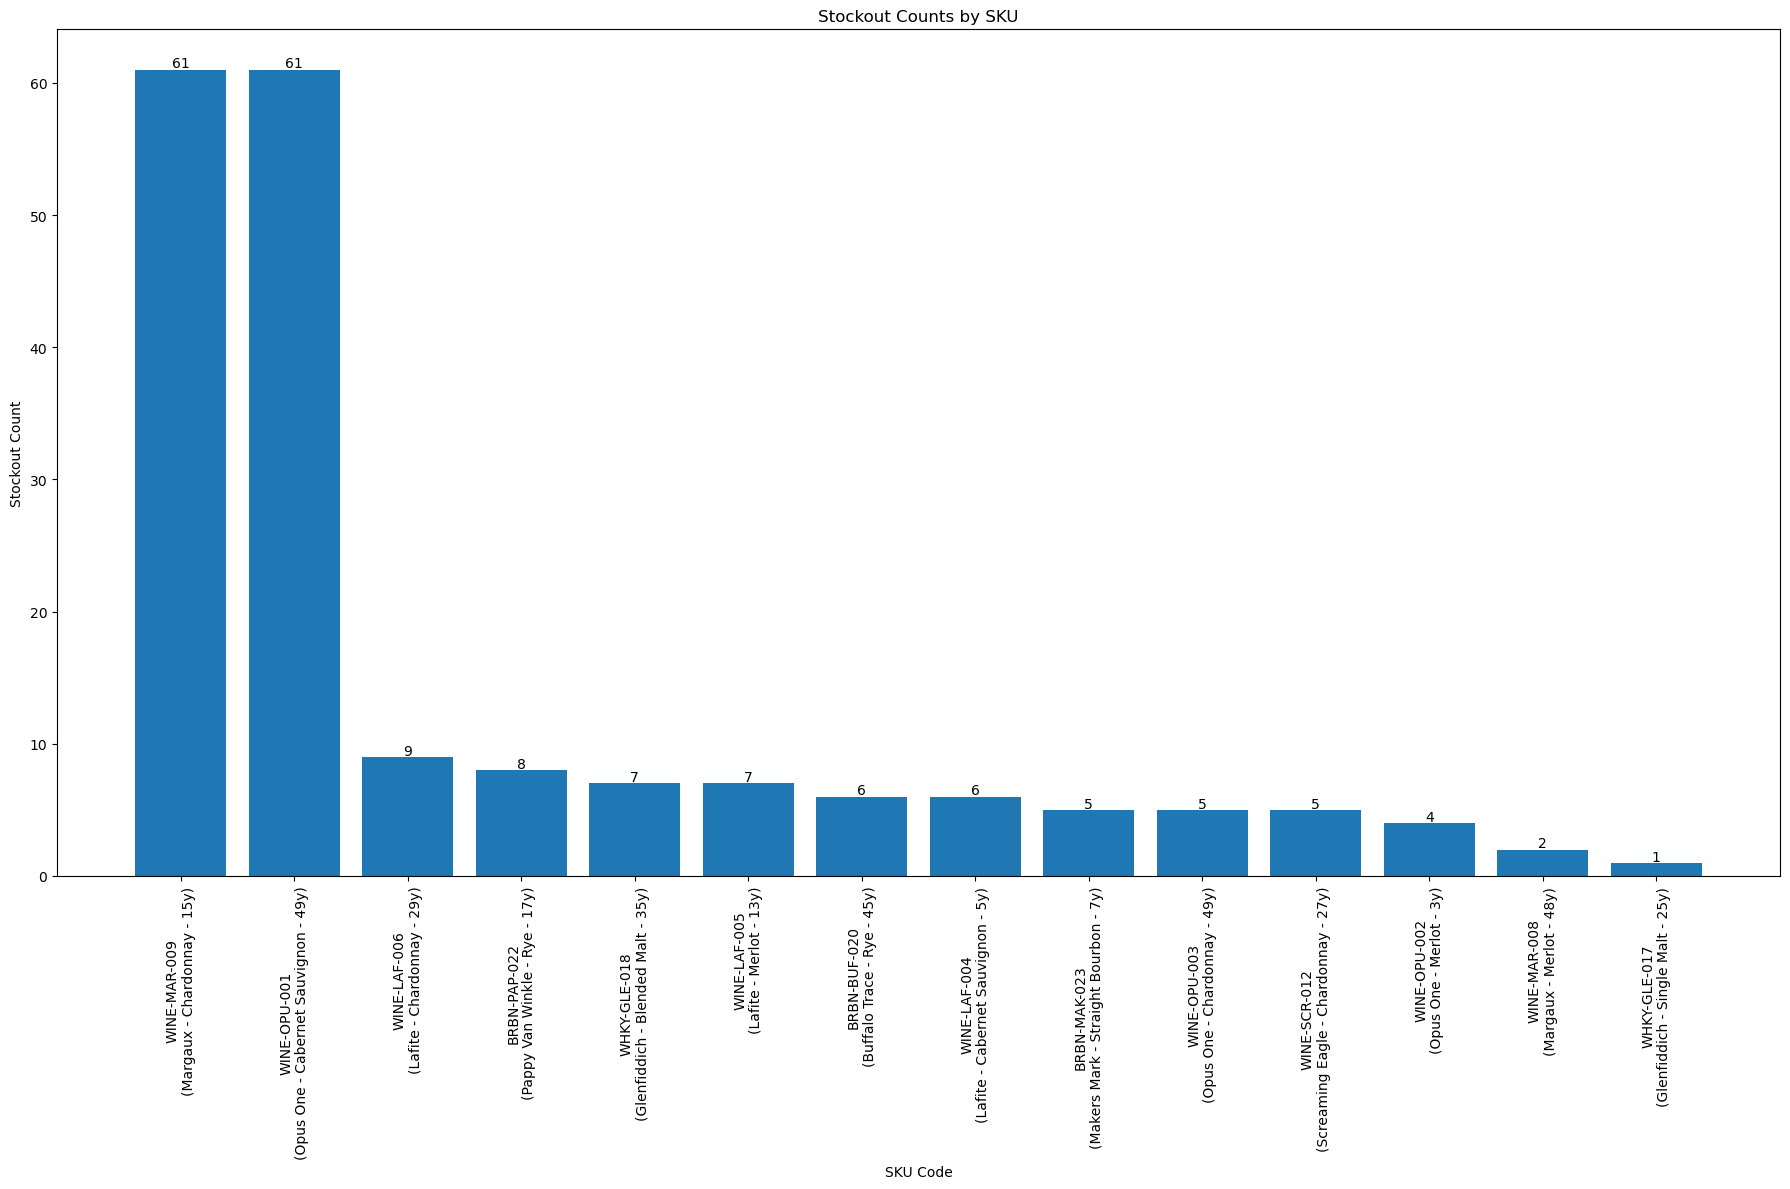

In [21]:
ops_txns_df = spark.sql("""
            select a.sku_code,
                a.snapshot_month,
                a.year,
                a.rank,
                cast(a.units_sold as int) as units_sold,
                cast(a.starting_inventory_position as int) as starting_inventory_position,
                cast(a.ending_inventory_position as int) as ending_inventory_position,
                a.inventory_turnover,
                a.stockout_flag,
                b.brand_name,
                b.age,
                c.product_category_name,
                c.sub_varietal_name,
                d.region_name,
                d.region_country_name
            from ops_txns a
            join d_skus b
                on a.sku_code = b.sku_code
            join d_products c
                on a.product_category_id = c.product_category_id
                and a.sub_varietal_id = c.sub_varietal_id
            join d_regions d
                on a.region_id = d.region_id
                and a.region_country_id = d.region_country_id
""").toPandas()
ops_txns_df['snapshot_month'] = pd.to_datetime(ops_txns_df['snapshot_month'])
ops_txns_df['product_name'] = ops_txns_df['brand_name'] + ' - ' + ops_txns_df['sub_varietal_name'] + ' - ' + ops_txns_df['age'].astype(str) + 'y'

stockout_df = ops_txns_df[ops_txns_df['stockout_flag'] == 1]

sku_to_product_name = ops_txns_df.set_index('sku_code')['product_name'].to_dict()

stockout_counts = stockout_df.groupby('sku_code').size().reset_index(name='stockout_count')

stockout_counts = stockout_counts.sort_values(by='stockout_count', ascending=False)

plt.figure(figsize=(18, 12))
bars = plt.bar(stockout_counts['sku_code'], stockout_counts['stockout_count'])
for bar in bars:
    height = bar.get_height()
    if height > 0:  
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height+1,  
            f'{int(height)}',  
            ha='center',
            va='top',
            fontsize=10  
        )


plt.xticks(
    ticks=range(len(stockout_counts['sku_code'])),
    labels=[f"{sku}\n({sku_to_product_name[sku]})" for sku in stockout_counts['sku_code']],
    rotation=90
)

plt.title('Stockout Counts by SKU')
plt.xlabel('SKU Code')
plt.ylabel('Stockout Count')
plt.tight_layout()
plt.show()

Based on this graph, 2 SKUs, `WINE-MAR-009` and `WINE-OPU-001` both have stockout (Net inventory position < 1000) every month in the dataset. Looking at the monthly rolling inventory quantities for these SKUs, we can see that these SKUs average only a few hundred units sold each month. This means our cutoff for flagging stockout at 1000 would not make sense for these SKUs; we'd need to allow for such SKUs to have a lower inventory position without flagging them for stockout.

In [23]:
ops_txns_df[ops_txns_df['sku_code']=='WINE-OPU-001'].head(200)

,sku_code,snapshot_month,year,rank,units_sold,starting_inventory_position,ending_inventory_position,inventory_turnover,stockout_flag,brand_name,age,product_category_name,sub_varietal_name,region_name,region_country_name,product_name
23,WINE-OPU-001,2020-01-01,2020,23,0,0,677,0.000000,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
47,WINE-OPU-001,2020-02-01,2020,24,384,677,573,0.614400,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
65,WINE-OPU-001,2020-03-01,2020,18,400,573,178,1.065246,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
95,WINE-OPU-001,2020-04-01,2020,24,48,178,616,0.120907,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
119,WINE-OPU-001,2020-05-01,2020,24,410,616,868,0.552561,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1353,WINE-OPU-001,2024-09-01,2024,10,148,394,827,0.242424,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
1372,WINE-OPU-001,2024-10-01,2024,5,354,827,996,0.388371,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
1396,WINE-OPU-001,2024-11-01,2024,5,397,996,939,0.410336,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y
1417,WINE-OPU-001,2024-12-01,2024,2,1077,939,467,1.532006,1,Opus One,49,Wine,Cabernet Sauvignon,Napa Valley,United States,Opus One - Cabernet Sauvignon - 49y


In [24]:
ops_txns_df[ops_txns_df['sku_code']=='WINE-MAR-009'].head(200)

,sku_code,snapshot_month,year,rank,units_sold,starting_inventory_position,ending_inventory_position,inventory_turnover,stockout_flag,brand_name,age,product_category_name,sub_varietal_name,region_name,region_country_name,product_name
12,WINE-MAR-009,2020-01-01,2020,13,200,0,166,2.409639,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
44,WINE-MAR-009,2020-02-01,2020,21,507,166,654,1.236585,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
70,WINE-MAR-009,2020-03-01,2020,23,282,654,514,0.482877,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
92,WINE-MAR-009,2020-04-01,2020,21,371,514,514,0.721790,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
117,WINE-MAR-009,2020-05-01,2020,22,483,514,462,0.989754,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,WINE-MAR-009,2024-09-01,2024,1,758,382,190,2.650350,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
1369,WINE-MAR-009,2024-10-01,2024,2,332,190,853,0.636625,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
1393,WINE-MAR-009,2024-11-01,2024,2,608,853,409,0.963550,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
1416,WINE-MAR-009,2024-12-01,2024,1,1064,409,384,2.683480,1,Margaux,15,Wine,Chardonnay,Napa Valley,United States,Margaux - Chardonnay - 15y
